In [480]:
%load_ext autoreload
%autoreload 2

import os
import glob
import sys
sys.path.insert(0, "../")

from pathlib import Path
import json

import pandas as pd
import seaborn as sns

from matplotlib.ticker import LogFormatterMathtext


import matplotlib
from matplotlib import pyplot as plt
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Switch between motif length and series-length experiments

In [513]:
max_memory = "2 GB"
experiment = "motif length"
# experiment = "series-length"

## Load data

In [514]:
# Noise relative to the amplitude of the sine wave
amplitude = 5.0

result_dir = Path("../tests/results/synthetic_scampi")

summary_path = result_dir / f"{experiment.replace(" ", "-")}_summary.csv"
jsonl_path = result_dir / f"{experiment.replace(" ", "-")}_runs.jsonl"

summary = pd.read_csv(summary_path)

with jsonl_path.open() as f:
  runs = [json.loads(line) for line in f]

# display(summary.head())

# Basic overview
summary[
  [
      "experiment",
      "n",
      "motif length",
      "noise",
      "seed",
      "scampi_delta",
      "scampi_max_memory",
      "time in s",
      "memory in MB",
      "selected extent",
      "precision",
      "recall",
      "f_score",
  ]
].head()


# Aggregate runtime and quality over seeds
x_col = "n" if experiment == "series-length" else "motif length"
summary = summary[summary["scampi_max_memory"] == max_memory].copy()

agg = (
  summary
  .groupby([x_col, "noise"], as_index=False)
  .agg(
      time_mean=("time in s", "mean"),
      time_std=("time in s", "std"),
      f_score_mean=("f_score", "mean"),
      precision_mean=("precision", "mean"),
      recall_mean=("recall", "mean"),
      extent_mean=("selected extent", "mean"),
  )
)


# Express noise relative to the motif amplitude
agg["relative_noise"] = agg["noise"] / amplitude
agg["relative_noise_pct"] = 100 * agg["relative_noise"]
agg["relative_noise_label"] = agg["relative_noise_pct"].map(
    lambda value: f"{value:g}%"
)

agg.head()

,motif length,noise,time_mean,time_std,f_score_mean,precision_mean,recall_mean,extent_mean,relative_noise,relative_noise_pct,relative_noise_label
0,256,0.00,9.187627,0.577180,1.0,1.0,1.0,2.849426e-08,0.00,0.0,0%
1,256,0.05,9.301546,0.349517,1.0,1.0,1.0,1.146169e-01,0.01,1.0,1%
2,256,0.10,9.095013,0.230438,1.0,1.0,1.0,4.586026e-01,0.02,2.0,2%
3,256,0.20,9.233797,0.402608,1.0,1.0,1.0,1.833174e+00,0.04,4.0,4%
4,256,0.25,9.457499,0.324400,1.0,1.0,1.0,2.861562e+00,0.05,5.0,5%


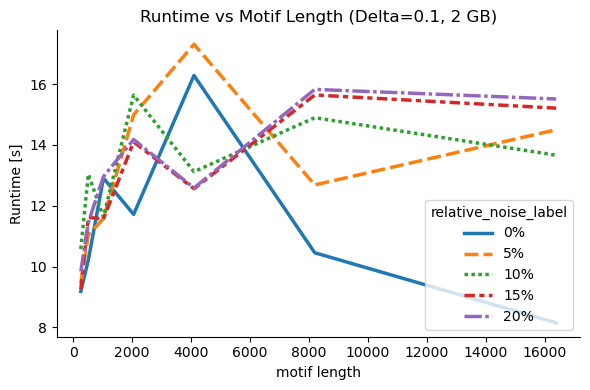

In [515]:
selected_noise = ["0%", "5%", "10%", "15%", "20%", "40%"]
plot_df = agg[agg["relative_noise_label"].isin(selected_noise)]

fig, ax = plt.subplots(figsize=(6, 4))

sns.lineplot(
    data=plot_df.sort_values(x_col),
    x=x_col,
    y="time_mean",
    hue="relative_noise_label",
    style="relative_noise_label",
    linewidth=2.5,    
    ax=ax,
)
sns.despine()

ax.set_xlabel(x_col)
ax.set_ylabel("Runtime [s]")
ax.set_title(f"Runtime vs {experiment.title() } (Delta=0.1, {max_memory})")

plt.tight_layout()
plt.savefig(f"images/synthetic_runtime_lineplot_{experiment.replace(" ","-")}.pdf")
plt.show()

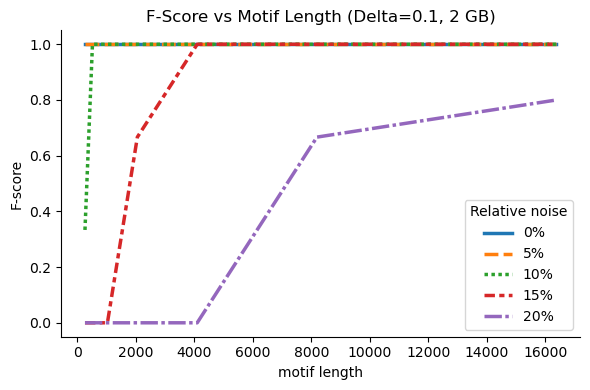

In [516]:
selected_noise = ["0%", "5%", "10%", "15%", "20%", "40%"]
plot_df = agg[agg["relative_noise_label"].isin(selected_noise)]

fig, ax = plt.subplots(figsize=(6, 4))

sns.lineplot(
    data=plot_df,
    x=x_col,
    y="f_score_mean",
    hue="relative_noise_label",
    style="relative_noise_label",
    linewidth=2.5, 
    ax=ax,
)


sns.despine()

#ax.set_xscale("log")
#ax.xaxis.set_major_formatter(LogFormatterMathtext())


ax.set_xlabel(x_col)
ax.set_ylabel("F-score")
ax.set_title(f"F-Score vs {experiment.title() } (Delta=0.1, {max_memory})")
ax.legend(title="Relative noise")
plt.tight_layout()
plt.savefig(f"images/synthetic_quality_lineplot_{experiment.replace(" ","-")}.pdf")
plt.show()

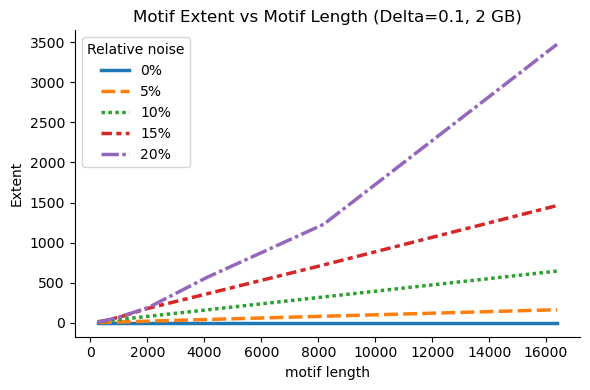

In [517]:
selected_noise = ["0%", "5%", "10%", "15%", "20%", "40%"]
plot_df = agg[agg["relative_noise_label"].isin(selected_noise)]

fig, ax = plt.subplots(figsize=(6, 4))

sns.lineplot(
    data=plot_df,
    x=x_col,
    y="extent_mean",
    hue="relative_noise_label",
    style="relative_noise_label",
    linewidth=2.5, 
    ax=ax,
)


sns.despine()

#ax.set_xscale("log")
# ax.xaxis.set_major_formatter(LogFormatterMathtext())
    
ax.set_xlabel(x_col)
ax.set_ylabel("Extent")
ax.set_title(f"Motif Extent vs {experiment.title() } (Delta=0.1, {max_memory})")
ax.legend(title="Relative noise")
plt.tight_layout()
plt.savefig(f"images/synthetic_quality2_lineplot_{experiment.replace(" ","-")}.pdf")
plt.show()

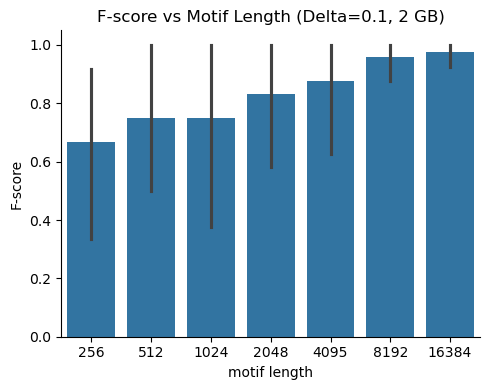

In [518]:
fig, ax = plt.subplots(figsize=(5, 4))

sns.barplot(
    data=agg,
    x=x_col,
    y="f_score_mean",
    # hue="relative_noise_label",
    legend=False,
    ax=ax,
)

sns.despine()

ax.set_xlabel(x_col)
ax.set_ylabel("F-score")
ax.set_title(f"F-score vs {experiment.title() } (Delta=0.1, {max_memory})")

plt.tight_layout()
plt.savefig(f"images/synthetic_quality_length_barplot_{experiment.replace(" ","-")}.pdf")
plt.show()

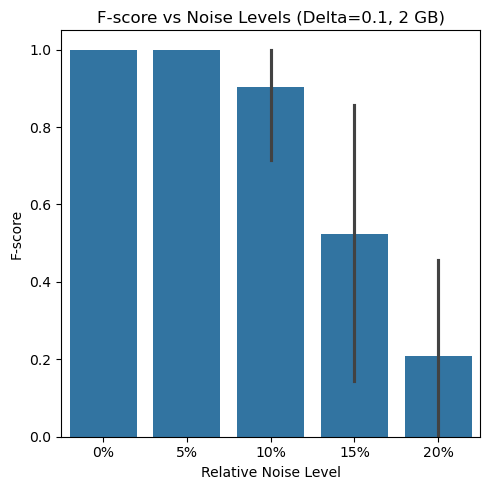

In [520]:
selected_noise = ["0%", "5%", "10%", "15%", "20%", "40%"]
plot_df = agg[agg["relative_noise_label"].isin(selected_noise)]

fig, ax = plt.subplots(figsize=(5, 5))

sns.barplot(
    data=plot_df,
    x="relative_noise_label",
    y="f_score_mean",
    #hue="relative_noise_label",
    ax=ax,
)

ax.set_xlabel("Relative Noise Level")
ax.set_ylabel("F-score")
# ax.set_ylim(0, 1.05)
ax.set_title(f"F-score vs Noise Levels (Delta=0.1, {max_memory})")

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"images/synthetic_quality_noise_barplot_{experiment.replace(" ","-")}.pdf")
plt.show()